In [30]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop

In additional to the usual python/astropy things, you'll need to install SynthPop, (maybe SPISEA, depending on your stellar evolution scheme in SynthPop), and PopSyCLE.
For SPISEA, it goes faster once you've made isochrones.

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

For PopSyCLE, it is required to use the popsycle_post_processing module to get your data in the right format. Additionally, you must use absolute magnitudes and use filters that PopSyCLE can interpret.

In [3]:
sp_mod = synthpop.SynthPop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           name_for_output='synthpopsycle', output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":False, "ifmr_name":'SukhboldN20'}, # IFMR
                                {"name": "popsycle_post_processing"}],
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"surot"}
                          )
sp_mod.init_populations()

 7343 - Execution Date: 22-07-2025 13:48:50


################################ Settings #################################
 7351 - # reading default parameters from
 7353 - default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 7361 - # read configuration from 
 7363 - config_file = '/u/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 7367 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "test_synthpopsycle",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1608652279,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,


Then, run the specific sightline you want

In [4]:
_ = sp_mod.process_location(-3.0, 4.0, # first, enter l and b in degrees
                            solid_angle=1e-2, solid_angle_unit='deg^2', # solid angle can be in deg^2 or sr
                            save_data=False) # this prevents synthpop from saving in its default format, it will instead save via popsycle_post_processing



############################# update location #############################
 37078 - # set location to: 
 37080 - l, b = (-3.00 deg, 4.00 deg)
 37083 - # set solid_angle to:
 37089 - solid_angle = 1.000e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 52096 - # From density profile (number density)
 52104 - expected_total_iMass = 1103307.6585
 52107 - expected_total_eMass = 601944.7635
 52109 - average_iMass_per_star = 0.5739
 52111 - mass_loss_correction = 0.5456
 52113 - n_expected_stars = 1922587.7619
 52143 - # Determine velocities when position are generated 


  0%|          | 0/1923806 [00:00<?, ?it/s]

 103401 - # From Generated Field:
 103405 - generated_stars = 1923806
 103466 - generated_total_iMass = 1103730.1605
 103593 - generated_total_eMass = 603643.4018
 103646 - det_mass_loss_corr = 0.5469
 106756 - # Done


# Population 1;  halo -----------------------------------------------------
 108301 - # From density profile (number density)
 108304 - expected_total_iMass = 1920.6836
 108306 - expected_total_eMass = 1014.4133
 108308 - average_iMass_per_star = 0.5739
 108310 - mass_loss_correction = 0.5282
 108312 - n_expected_stars = 3346.9204
 108318 - # Determine velocities when position are generated 
 108594 - # From Generated Field:
 108596 - generated_stars = 3379
 108599 - generated_total_iMass = 1811.1912
 108613 - generated_total_eMass = 1012.7558
 108615 - det_mass_loss_corr = 0.5592
 108678 - # Done


# Population 2;  nsd ------------------------------------------------------
 111293 - # From density profile (number density)
 111295 - expected_total_iMass = 0.0000
 111297

In [19]:
sp_mod.parms.output_filename_pattern

'{name_for_output}'

# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [5]:
synthetic.calc_events(hdf5_file = 'synthpop_test.h5', 
                      output_root2 = 'synthpop_test', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = True, 
                      n_proc = 1)

Working on loop ll, bb =  0 0
Working on loop ll, bb =  0 1
Working on loop ll, bb =  0 2
Working on loop ll, bb =  0 3
Working on loop ll, bb =  0 4
Working on loop ll, bb =  1 0
Working on loop ll, bb =  1 1
Working on loop ll, bb =  1 2
Working on loop ll, bb =  1 3
Working on loop ll, bb =  1 4
Working on loop ll, bb =  2 0
Working on loop ll, bb =  2 1
Working on loop ll, bb =  2 2
Working on loop ll, bb =  2 3
Working on loop ll, bb =  2 4
Working on loop ll, bb =  3 0
Working on loop ll, bb =  3 1
Working on loop ll, bb =  3 2
Working on loop ll, bb =  3 3
Working on loop ll, bb =  3 4
Working on loop ll, bb =  4 0
Working on loop ll, bb =  4 1
Working on loop ll, bb =  4 2
Working on loop ll, bb =  4 3
Working on loop ll, bb =  4 4
Candidate events detected:  89
calc_events runtime : 295.211035 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [6]:
synthetic.refine_events(input_root = 'synthpop_test', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  76
Candidate events in survey window:  67
refine_events runtime : 0.256423 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [12]:
t = Table.read('synthpop_test_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'systemMass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'ubv_U_L', 'ubv_I_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'isMultiple_L', 'N_companions_L', 'rem_id_L', 'obj_id_L', 'zams_mass_S', 'mass_S', 'systemMass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'ubv_U_S', 'ubv_I_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'isMultiple_S', 'N_companions_S', 'rem_id_S', 'obj_id_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [13]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 2
Number of NSs: 0
Number of WDs: 11
Number of stars: 54


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

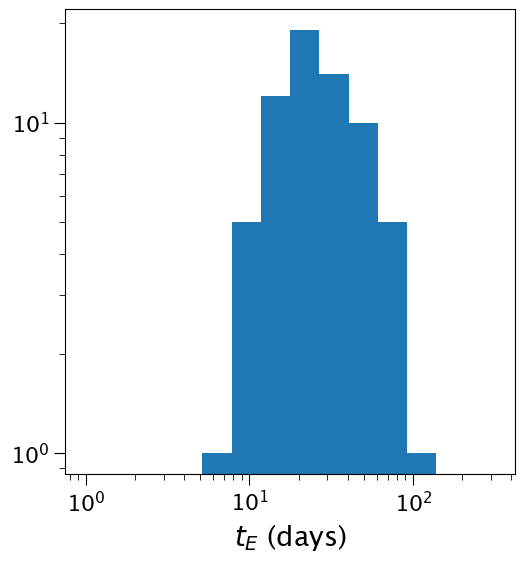

In [14]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

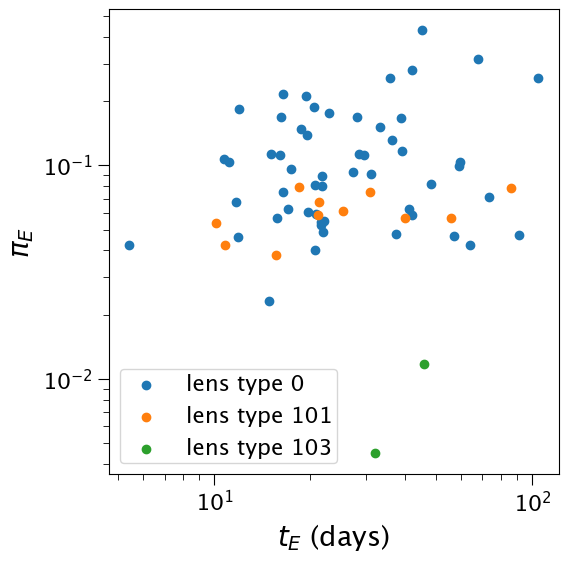

In [29]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label='lens type '+str(rem_id))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend()

## dL vs dS

Text(0, 0.5, '$d_S$ (kpc)')

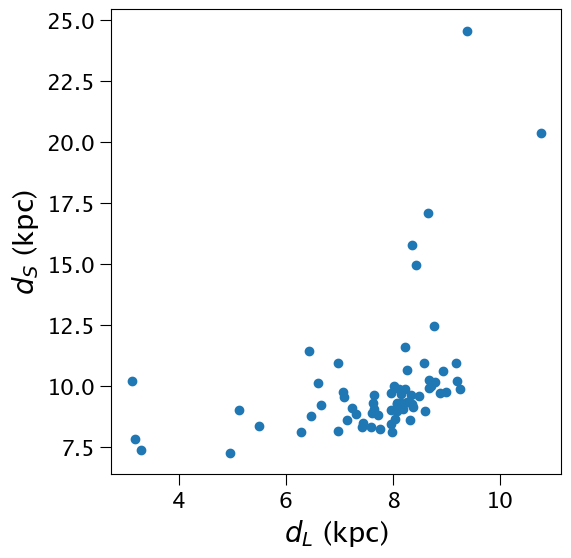

In [16]:
plt.scatter(t['rad_L'], t['rad_S'])
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')